In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import librosa.display

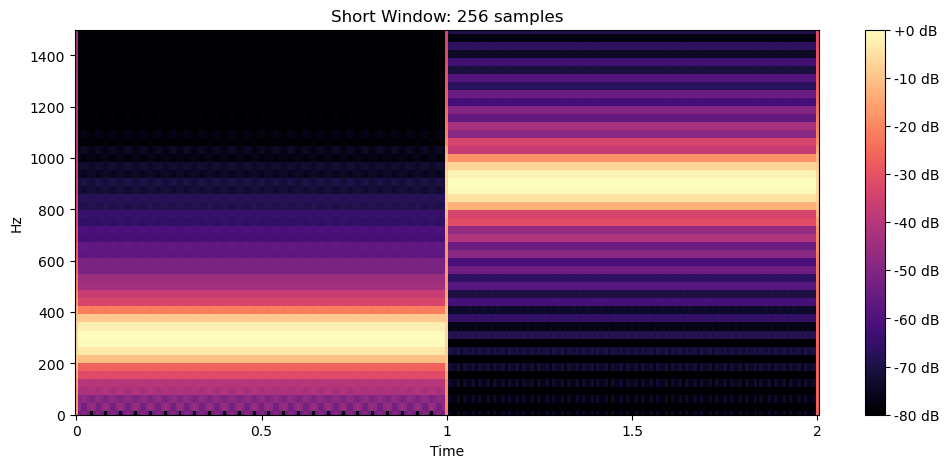

In [4]:
sample_rate = 16000 
duration = 2.0

N = int(sample_rate * duration)

time = np.arange(N)/sample_rate

signal = np.zeros(N)

# 0-1 second -> 300 Hz
signal[:sample_rate] = np.sin(
    2 * np.pi * 300 * time[:sample_rate]
)

# 1-2 seconds -> 900 Hz
signal[sample_rate:] = np.sin(
    2 * np.pi * 900 * time[sample_rate:]
)

#short window

stft_short = librosa.stft(
    signal,
    n_fft=512,
    win_length=256,
    hop_length=128
)

short_db = librosa.amplitude_to_db(
    np.abs(stft_short),
    ref=np.max
)

plt.figure(figsize = (12,5))

librosa.display.specshow(
    short_db,
    sr=sample_rate,
    hop_length=128,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Short Window: 256 samples")
plt.ylim(0, 1500)
plt.show()



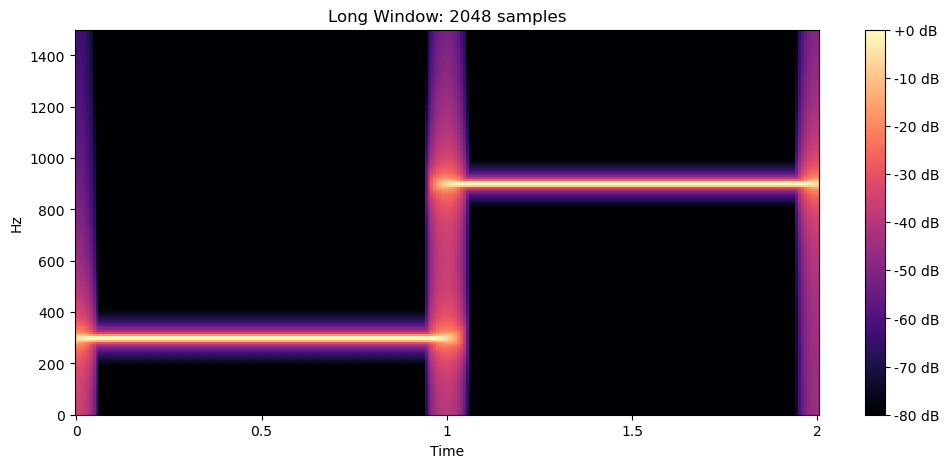

In [5]:
# --------------------------------------------------
# Long window
# --------------------------------------------------

stft_long = librosa.stft(
    signal,
    n_fft=2048,
    win_length=2048,
    hop_length=128
)

long_db = librosa.amplitude_to_db(
    np.abs(stft_long),
    ref=np.max
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    long_db,
    sr=sample_rate,
    hop_length=128,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Long Window: 2048 samples")
plt.ylim(0, 1500)
plt.show()

In [ ]:
# diff between n_fft and window_length

# window_length is the actual observation duration win_len / 16000 = xms of observation
# or no of real signal samples considered in a stft frame

#     whereas, 

# n_fft = deciding how many points will be provided to fft fn , if n_fft > window_len we pad

"""
we also want to understand why thick and sleek lines of magnitude in cases of short vs long windows

because the window is short , frequency cycles covered would be less


Why does a shorter STFT window produce a thicker frequency band?

Suppose the signal contains a 300 Hz sinusoid and the sample rate is 16 kHz.

If:

    win_length = 256

then one STFT frame contains:

    256 / 16000 = 0.016 s = 16 ms

A 300 Hz sinusoid completes:

    300 * 0.016 = 4.8 cycles

inside that frame.

The important point is that the thickness of the frequency band is determined by
what happens inside each individual STFT frame, not by how many frames exist.

The FFT effectively asks:

    "How strongly does this short signal segment match different frequencies?"

When the observation window is short, nearby frequencies such as 290 Hz,
300 Hz, 310 Hz, etc. can still look quite similar over that short duration.

There has not been enough time for the wrong frequencies to drift significantly
out of phase with the actual 300 Hz signal.

Therefore, several nearby frequencies produce reasonably strong FFT responses.

This causes the magnitude around 300 Hz to spread over a wider frequency range,
forming a broad main lobe.

In the spectrogram, this appears as a thicker horizontal band.

If we use a longer window, for example 2048 samples:

    2048 / 16000 = 0.128 s = 128 ms

then the 300 Hz signal completes:

    300 * 0.128 = 38.4 cycles

Now nearby frequencies have much more time to drift out of phase with the
300 Hz signal.

When their correlations are summed over the longer frame, the mismatches cancel
more strongly.

Therefore:

    Short window
        -> fewer observed cycles
        -> nearby frequencies still look similar
        -> magnitude spreads across a wider frequency range
        -> thicker frequency band

    Long window
        -> more observed cycles
        -> nearby frequencies diverge more clearly
        -> magnitude concentrates more tightly around the true frequency
        -> thinner frequency band

Important distinction:

    Window length affects frequency resolution inside each frame.

    Hop length affects how many frames are produced over time.

So the vertical thickness of a spectrogram band comes from frequency-domain
spread within each frame, not from the number of STFT frames.

Also, individual samples are not "300 Hz samples."
Each sample is only an amplitude value. A sequence of samples over time
represents the 300 Hz oscillation.
"""
